In [ ]:
import cv2
from google.cloud import vision
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Sequence, Tuple

In [8]:
cap = cv2.VideoCapture('data/5 min 25 C 0.1 M 186 mOsm NaCl and Pure water in 2.0 mg trans DOPC and 0.5 mg CHOL in 300 microliters SqE 1001.avi')
_, image = cap.read()
# image = cv2.normalize(src=image, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
(thresh, bw_image) = cv2.threshold(gray_image, 90, 255, cv2.THRESH_BINARY)
# cv2.imshow('frame', frame)
# cap.release()

In [63]:
print(image.shape)
print(gray_image.shape)

(1080, 1920, 3)
(1080, 1920)


In [160]:
# img = image
# img = gray_image
img = bw_image
circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, dp=1.5, minDist=100,
                           minRadius=100, param1=900, param2=70)
# circles = cv2.HoughCircles(
#     img, method=cv2.HOUGH_GRADIENT_ALT, dp=1.5, minDist=100,
#     param1=1000, param2=0.01, minRadius=10,
# )
# circles = cv2.HoughCircles(
#     img, method=cv2.HOUGH_GRADIENT_ALT, dp=1, minDist=10,
#     param1=100, param2=0.9, minRadius=10,
# )
# circles = cv2.HoughCircles(
#     img, method=cv2.HOUGH_GRADIENT_ALT, dp=1, minDist=10,
#     param1=300, param2=0.9, minRadius=10,
# )
circles

array([[[1509.75   ,  440.25   ,  246.70001],
        [ 390.75   ,  551.25   ,  334.45   ],
        [ 981.75   , 1041.75   ,  556.30005],
        [1308.75   , 1041.75   ,  883.14996],
        [1457.25   , 1041.75   ,  848.5    ],
        [1113.75   , 1038.75   ,  474.55   ],
        [ 789.75   , 1047.75   ,  834.1    ],
        [ 606.75   ,  462.75   ,  173.95   ],
        [1712.25   , 1038.75   ,  849.69995],
        [   2.25   , 1041.75   ,  424.3    ],
        [1892.25   , 1041.75   ,  935.5    ],
        [ 531.75   ,  627.75   ,  235.75   ],
        [1539.75   ,  581.25   ,  123.4    ],
        [ 597.75   , 1038.75   ,  172.15   ]]], dtype=float32)

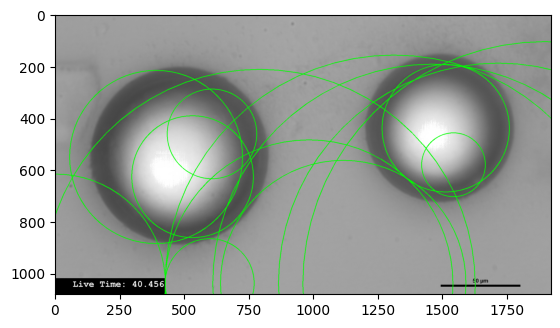

In [161]:
img = image
# img = bw_image
image2 = img.copy()
for (x, y, r) in circles[0]:
#     cv2.circle(image, (x, y), r, (0, 255, 0), 2)
    cv2.circle(image2, (int(x), int(y)), int(r), (0, 255, 0), 2)    
plt.imshow(image2, cmap='gray')
# plt.imshow(gray_image, cmap='gray')

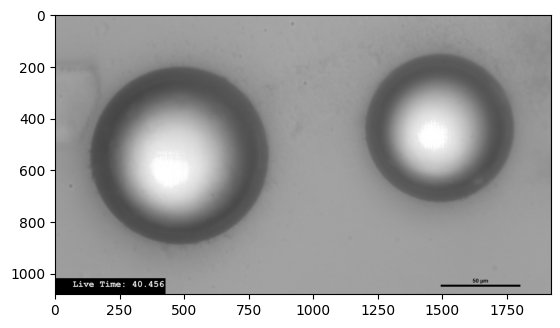

In [4]:
plt.imshow(image, cmap='gray')

In [ ]:
img = image.copy()
detector = cv2.SimpleBlobDetector()

# detector.set_min_size(10, 10)
# detector.set_max_size(20, 20)
# detector.set_threshold(100)

keypoints = detector.detect(img)
# cv2.drawKeypoints(img, keypoints, None, (0, 0, 255), 2)
# plt.imshow(img, cmap='gray')

In [72]:
def analyze_image_from_uri(
    image_uri: str,
    feature_types: Sequence,
) -> vision.AnnotateImageResponse:
    client = vision.ImageAnnotatorClient()

    image = vision.Image()
    image.source.image_uri = image_uri
    features = [vision.Feature(type_=feature_type) for feature_type in feature_types]
    request = vision.AnnotateImageRequest(image=image, features=features)

    response = client.annotate_image(request=request)

    return response


def analyze_image_from_bytes(
    image_bytes: bytes,
    feature_types: Sequence,
) -> vision.AnnotateImageResponse:
    client = vision.ImageAnnotatorClient()

    image = vision.Image(content=image_bytes)
    features = [vision.Feature(type_=feature_type) for feature_type in feature_types]
    request = vision.AnnotateImageRequest(image=image, features=features)

    response = client.annotate_image(request=request)

    return response


def print_objects(response: vision.AnnotateImageResponse):
    print("=" * 80)
    for obj in response.localized_object_annotations:
        nvertices = obj.bounding_poly.normalized_vertices
        print(
            f"{obj.score:4.0%}",
            f"{obj.name:15}",
            f"{obj.mid:10}",
            ",".join(f"({v.x},{v.y})" for v in nvertices),
            sep=" | ",
        )
        

# def get_attributes(response: vision.AnnotateImageResponse) -> List[Tuple[float, float, float]]:
#     circles = []
#     for obj in response.localized_object_annotations:
#         nvertices = obj.bounding_poly.normalized_vertices
#         x_values = [v.x for v in nvertices]
#         y_values = [v.y for v in nvertices]
#         radius_x = max(x_values) - min(x_values)
#         radius_y = max(y_values) - min(y_values)
#         radius = (radius_x + radius_y) / 2
#         center_x = min(x_values) + radius_x
#         center_y = min(y_values) + radius_y
#         circles.append((center_x, center_y, radius))
#     return circles


def get_bounding_boxes(
    response: vision.AnnotateImageResponse) -> List[Tuple[float, float, float, float]]:
    bounding_boxes = []
    for obj in response.localized_object_annotations:
        top_left = obj.bounding_poly.normalized_vertices[0]
        bottom_right = obj.bounding_poly.normalized_vertices[2]
        bounding_boxes.append((top_left.x, bottom_right.x, top_left.y, bottom_right.y))
    return bounding_boxes


def unnormalize_bounding_box(
    image: np.ndarray,
    x1: float, x2: float, y1: float, y2: float) -> Tuple[float, float, float, float]:
    return (
        x1 * image.shape[1], x2 * image.shape[1],
        y1 * image.shape[0], y2 * image.shape[0],
    )


def circle_from_bounding_box(
    x1: float, x2: float, y1: float, y2: float) -> Tuple[float, float, float]:
    return (
        (x1 + x2) / 2,
        (y2 + y1) / 2,
        (((x2 - x1) / 2) + ((y2 - y1) / 2)) / 2,
    )
    

In [33]:
success, encoded_image = cv2.imencode('.png', image)
content = encoded_image.tobytes()

In [76]:
features = [vision.Feature.Type.OBJECT_LOCALIZATION]
response = analyze_image_from_bytes(content, features)
print_objects(response)

 73% | Ball            | /m/018xm   | (0.06406558305025101,0.18635495007038116),(0.42722412943840027,0.18635495007038116),(0.42722412943840027,0.8212775588035583),(0.06406558305025101,0.8212775588035583)
 71% | Ball            | /m/018xm   | (0.6185159683227539,0.13650701940059662),(0.9194194674491882,0.13650701940059662),(0.9194194674491882,0.6686067581176758),(0.6185159683227539,0.6686067581176758)


In [73]:
normalized_bounding_boxes = get_bounding_boxes(response)
bounding_boxes = [unnormalize_bounding_box(image, *b) for b in normalized_bounding_boxes]
bounding_boxes
circles = [circle_from_bounding_box(*b) for b in bounding_boxes]
circles

[(471.6381239891052, 544.1215547919273, 345.7452066242695),
 (1476.4180183410645, 434.7614398598671, 288.10060903429985)]

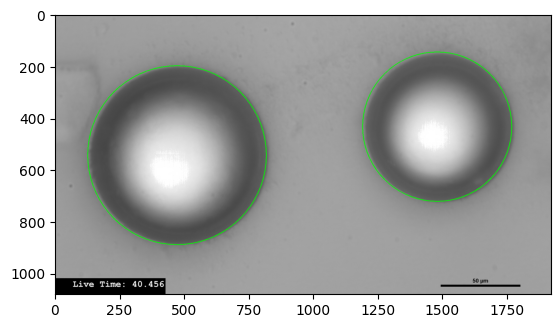

In [74]:
img = image
# img = bw_image
image2 = img.copy()
for (x, y, r) in circles:
    cv2.circle(
        image2,
        (int(x), int(y)), int(r),
        (0, 255, 0), 2)    

    
plt.imshow(image2, cmap='gray')
# plt.imshow(gray_image, cmap='gray')

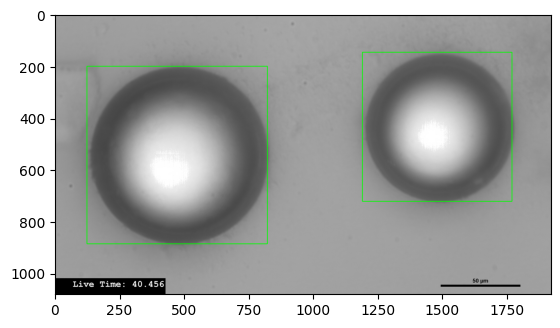

In [68]:
img = image
# img = bw_image
image2 = img.copy()
for (x1, x2, y1, y2) in bounding_boxes:
    cv2.rectangle(
        image2,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0), 2)    
    
plt.imshow(image2, cmap='gray')
# plt.imshow(gray_image, cmap='gray')

[x: 0.0640655831
y: 0.18635495
, x: 0.427224129
y: 0.18635495
, x: 0.427224129
y: 0.821277559
, x: 0.0640655831
y: 0.821277559
]

In [75]:
features

[<Type.OBJECT_LOCALIZATION: 19>]